## Notebook for using the CDS API to get ERA5 data - turns out multiple parallel scripts is a bad idea

#### Run the pip install to get the latest cdsapi

In [1]:
#!pip install cdsapi
!pip install --upgrade cdsapi
# created .cdsapirc file in ~/  per https://ads-beta.atmosphere.copernicus.eu/how-to-api

In [1]:
import cdsapi
import requests
import os

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

# *** 1 Deg ERA5 ***

In [2]:
!ls -al "../../../Data/ERA5-1deg/raw"

total 24
drwxr-xr-x@ 33 tedscott  staff   1056 Sep 29 11:28 .
drwxr-xr-x@  5 tedscott  staff    160 Sep 29 12:21 ..
-rw-r--r--@  1 tedscott  staff  10244 Sep 29 16:02 .DS_Store
drwxr-xr-x@ 14 tedscott  staff    448 Sep 29 11:58 1961
drwxr-xr-x@ 14 tedscott  staff    448 Sep 29 12:40 1962
drwxr-xr-x@ 14 tedscott  staff    448 Sep 29 16:02 1963
drwxr-xr-x@  2 tedscott  staff     64 Sep 29 11:28 1964
drwxr-xr-x@  2 tedscott  staff     64 Sep 29 11:28 1965
drwxr-xr-x@  2 tedscott  staff     64 Sep 29 11:28 1966
drwxr-xr-x@  2 tedscott  staff     64 Sep 29 11:28 1967
drwxr-xr-x@  2 tedscott  staff     64 Sep 29 11:28 1968
drwxr-xr-x@  2 tedscott  staff     64 Sep 29 11:28 1969
drwxr-xr-x@  2 tedscott  staff     64 Sep 29 11:28 1970
drwxr-xr-x@  2 tedscott  staff     64 Sep 29 11:28 1971
drwxr-xr-x@  2 tedscott  staff     64 Sep 29 11:28 1972
drwxr-xr-x@  2 tedscott  staff     64 Sep 29 11:28 1973
drwxr-xr-x@  2 tedscott  staff     64 Sep 29 11:28 1974
drwxr-xr-x@  2 tedscott  staff     64 S

In [3]:
for i in np.arange(1991,2027,1):
    directory_name = "../../../Data/ERA5-1deg/raw/"+str(i)
    try:
        os.mkdir(directory_name)
        print(f"Directory '{directory_name}' created successfully.")
    except FileExistsError:
        print(f"Directory '{directory_name}' already exists.")

Directory '../../../Data/ERA5-1deg/raw/1991' created successfully.
Directory '../../../Data/ERA5-1deg/raw/1992' created successfully.
Directory '../../../Data/ERA5-1deg/raw/1993' created successfully.
Directory '../../../Data/ERA5-1deg/raw/1994' created successfully.
Directory '../../../Data/ERA5-1deg/raw/1995' created successfully.
Directory '../../../Data/ERA5-1deg/raw/1996' created successfully.
Directory '../../../Data/ERA5-1deg/raw/1997' created successfully.
Directory '../../../Data/ERA5-1deg/raw/1998' created successfully.
Directory '../../../Data/ERA5-1deg/raw/1999' created successfully.
Directory '../../../Data/ERA5-1deg/raw/2000' created successfully.
Directory '../../../Data/ERA5-1deg/raw/2001' created successfully.
Directory '../../../Data/ERA5-1deg/raw/2002' created successfully.
Directory '../../../Data/ERA5-1deg/raw/2003' created successfully.
Directory '../../../Data/ERA5-1deg/raw/2004' created successfully.
Directory '../../../Data/ERA5-1deg/raw/2005' created successfu

## Pull daily stats by month for desired years

In [5]:
# move years and months to separate block?
#yrs = np.arange(1961,1991,1)
years = [str(i) for i in np.arange(1991,2011,1)]
years


['1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010']

In [6]:
# modified example code from https://confluence.ecmwf.int/display/CKB/ERA5+family+post-processed+daily+statistics+documentation

#196years = [ "1961",# "2026"]

months = [
         "01", 
     "02", "03",
         "04", "05", "06","07",
     "08", "09",
         "10", "11", "12"
        ]

var = '2m_temperature'

stat = 'daily_mean'

for yr in years:
    for mn in months:

        dataset = "derived-era5-single-levels-daily-statistics"
        request = {
            "product_type": "reanalysis",
            "variable": var,
            "year": yr,
            "month": mn,
            "day": [
                "01", "02", "03",
                "04", "05", "06",
                "07", "08", "09",
                "10", "11", "12",
                "13", "14", "15",
                "16", "17", "18",
                "19", "20", "21",
                "22", "23", "24",
                "25", "26", "27",
                "28", "29", "30",
                "31"
            ],
            "daily_statistic": stat,
            "time_zone": "utc+00:00",
            "frequency": "1_hourly",
            'grid': [1.0, 1.0] # 1 degree
        }
        target = "../../../Data/ERA5-1deg/raw/" + yr + "/download_" + stat + "_" + var + "_" + yr + "_" + mn + ".nc"
        client = cdsapi.Client()
        client.retrieve(dataset, request, target)#.download()
        

2026-09-29 16:10:33,881 INFO Request ID is 95fec389-e1ed-471d-83eb-550ecf7f4c77
2026-09-29 16:10:34,164 INFO status has been updated to accepted
2026-09-29 16:43:14,853 INFO status has been updated to successful


184339628c0428e8b9a8009dc0592aef.nc:   0%|          | 0.00/4.15M [00:00<?, ?B/s]

2026-09-29 16:43:21,278 INFO Request ID is e30a55a0-44a1-467b-8cea-d5f7137148e4
2026-09-29 16:43:21,501 INFO status has been updated to accepted
2026-09-29 17:28:12,347 INFO status has been updated to successful


2aa0cfb786960f52decf76cea09bce84.nc:   0%|          | 0.00/3.75M [00:00<?, ?B/s]

2026-09-29 17:28:18,946 INFO Request ID is 96c625db-4bce-43ca-8be6-94af9d155049
2026-09-29 17:28:19,358 INFO status has been updated to accepted
2026-09-29 18:49:39,352 INFO status has been updated to successful


...

d5fb514aa036d8382ad873e93854773f.nc:   0%|          | 0.00/3.98M [00:00<?, ?B/s]

2026-09-30 06:06:51,411 INFO Request ID is 4c11c2e6-43d4-4941-8e75-6d59bbe356dc
2026-09-30 06:06:51,637 INFO status has been updated to accepted
2026-09-30 08:12:47,110 INFO status has been updated to successful


d2591f3c34a503d1242cd5f7014e3659.nc:   0%|          | 0.00/4.14M [00:00<?, ?B/s]

2026-09-30 08:12:53,399 INFO Request ID is 3fc5b06e-909d-46f1-ac25-77d611e0f017
2026-09-30 08:12:53,721 INFO status has been updated to accepted


KeyboardInterrupt: 

### check out contents of one of the downloads

In [5]:
# filename ERA5_T2m_202106_PugetSound.nc
dset = xr.open_dataset('../../../Data/ERA5-1deg/raw/1961/download_daily_mean_2m_temperature_1961_01.nc')
dset

<xarray.Dataset> Size: 8MB
Dimensions:     (valid_time: 31, latitude: 181, longitude: 360)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 248B 1961-01-01 ... 1961-01-31
  * latitude    (latitude) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * longitude   (longitude) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-29T17:48 GRIB to CDM+CF via cfgrib-0.9.1...

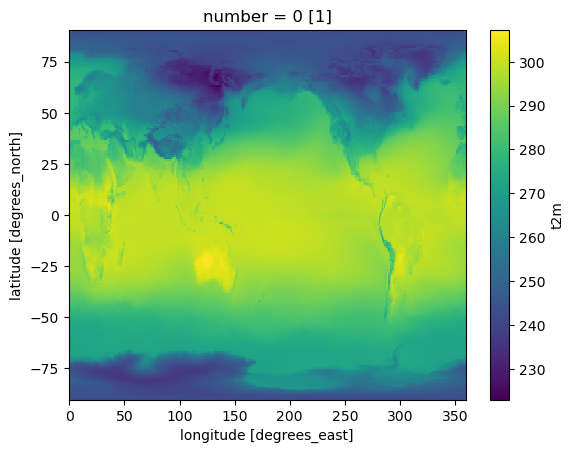

In [7]:
dset.t2m.mean(dim='valid_time').plot()

## Correct lat/lon ranges and naming

#### create folders if needed

In [28]:
!ls -al "../../../Data/ERA5-1deg/FixedCoords"

total 16
drwxr-xr-x@ 6 tedscott  staff   192 Sep 29 11:22 .
drwxr-xr-x@ 4 tedscott  staff   128 Sep 29 10:49 ..
-rw-r--r--@ 1 tedscott  staff  6148 Sep 29 11:22 .DS_Store
drwxr-xr-x@ 3 tedscott  staff    96 Sep 29 10:49 1961
drwxr-xr-x@ 2 tedscott  staff    64 Sep 29 11:17 1962
drwxr-xr-x@ 2 tedscott  staff    64 Sep 29 11:17 1963


In [32]:
for i in np.arange(1961,1991,1):
    directory_name = "../../../Data/ERA5-1deg/FixedCoords/"+str(i)
    try:
        os.mkdir(directory_name)
        print(f"Directory '{directory_name}' created successfully.")
    except FileExistsError:
        print(f"Directory '{directory_name}' already exists.")

../../../Data/ERA5-1deg/raw/1990/
Directory '../../../Data/ERA5-1deg/raw/1964' created successfully.
../../../Data/ERA5-1deg/raw/1990/
Directory '../../../Data/ERA5-1deg/raw/1965' created successfully.
../../../Data/ERA5-1deg/raw/1990/
Directory '../../../Data/ERA5-1deg/raw/1966' created successfully.
../../../Data/ERA5-1deg/raw/1990/
Directory '../../../Data/ERA5-1deg/raw/1967' created successfully.
../../../Data/ERA5-1deg/raw/1990/
Directory '../../../Data/ERA5-1deg/raw/1968' created successfully.
../../../Data/ERA5-1deg/raw/1990/
Directory '../../../Data/ERA5-1deg/raw/1969' created successfully.
../../../Data/ERA5-1deg/raw/1990/
Directory '../../../Data/ERA5-1deg/raw/1970' created successfully.
../../../Data/ERA5-1deg/raw/1990/
Directory '../../../Data/ERA5-1deg/raw/1971' created successfully.
../../../Data/ERA5-1deg/raw/1990/
Directory '../../../Data/ERA5-1deg/raw/1972' created successfully.
../../../Data/ERA5-1deg/raw/1990/
Directory '../../../Data/ERA5-1deg/raw/1973' created succ

In [ ]:
# years and months to correct
years = [str(i) for i in np.arange(1961,1991,1)]

# need the 0 for single digit months
months = ["01", "02", "03",
          "04", "05", "06",
          "07", "08", "09",
          "10", "11", "12"]

years

In [ ]:
%%time

# build filenames and loop

for y in years:
    for m in months:
        #filepath = '../../../Data/ERA5-1deg/raw/1961/download_daily_mean_2m_temperature_1961_01.nc'
        filepath = '../../../Data/ERA5-1deg/raw/'+str(y)+'/download_daily_mean_2m_temperature_'+str(y)+'_' + str(m) + '.nc'
        ds = xr.open_dataset(filepath)
    
        # adjust longitude to run from -180 to 180
        lon_atrib = ds.coords['longitude'].attrs  
        lat_atrib = ds.coords['latitude'].attrs
        time_atrib = ds.coords['valid_time'].attrs
        ds.coords['longitude'] = (ds.coords['longitude'] + 180) % 360 - 180
        ds = ds.sortby(ds.longitude)
    
        # now adjust latitude to run from -90 to 90 like my pre-2025 data
        ds = ds.isel(latitude=slice(None, None, -1))
    
        # rename to lat and lon like the t2m data and update attributes
        dst = ds.rename({'valid_time':'time','longitude':'lon','latitude':'lat'})
        dst.coords['lon'].attrs = lon_atrib
        dst.coords['lat'].attrs = lat_atrib
        dst.coords['time'].attrs = time_atrib
    
        # drop the experiment number so it doesn't break merging later
        dst = dst.drop_vars("number")
    
        # save it out 
        outpath = '../../../Data/ERA5-1deg/FixedCoords/'+str(y)+'/download_daily_mean_2m_temperature_'+str(y)+'_' + str(m) + '.nc'
        dst.to_netcdf(outpath)

### Confirm all looks good

In [5]:
# filename ERA5_T2m_202106_PugetSound.nc
dset = xr.open_dataset('../../../Data/ERA5-1deg/FixedCoords/1961/download_daily_mean_2m_temperature_1961_01.nc')
dset

<xarray.Dataset> Size: 8MB
Dimensions:     (valid_time: 31, latitude: 181, longitude: 360)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 248B 1961-01-01 ... 1961-01-31
  * latitude    (latitude) float64 1kB 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * longitude   (longitude) float64 3kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-29T17:48 GRIB to CDM+CF via cfgrib-0.9.1...